# ML Feature Engineering — Base Features (Phase A), Split Manifests (Phase B) & Dev Audit

Olist Brazilian E-Commerce — IT5006 Group 11 · ML dataset pipeline.

This notebook **imports and calls** the reusable modules under `src/features/`
(per `data/business/ml/feature_contract.md` v1.2 §11.2 — it does **not** embed
copies of their source), reproduces every `data/business/ml/` artifact
end-to-end, and adds a **development-only feature audit** for the two eligible
task populations.

| Artifact | Phase |
| --- | --- |
| `orders_ml_features.csv` | A |
| `feature_schema.json` | A |
| `dataset_manifest.json` | A |
| `zip_centroids.csv` | A |
| `quality_report.json` | A |
| `split_assignments.csv` | B |
| `cv_assignments.csv` | B |
| `split_report.json` | B |

**Lineage:** `data/preprocessed/*.csv → src/features/ → data/business/ml/`.
ML never reads `data/raw/` or `data/business/dashboard/`.

## 0. Environment & repo root

Locate the repository root relative to wherever the notebook runs, so the
`src.features` package resolves without hard-coded paths.

In [1]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "preprocessed").is_dir() and (p / "src" / "features").is_dir():
            return p
    raise FileNotFoundError("repo root not found (needs data/preprocessed and src/features)")

ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)

import numpy, pandas, sklearn, geopandas, shapely, pyproj
print("pandas", pandas.__version__, "| numpy", numpy.__version__)
print("sklearn", sklearn.__version__, "| geopandas", geopandas.__version__,
      "| shapely", shapely.__version__, "| pyproj", pyproj.__version__)

repo root: c:\src\IT5006_prj
pandas 2.3.2 | numpy 2.3.2
sklearn 1.8.0 | geopandas 1.2.0 | shapely 2.1.2 | pyproj 3.8.0


## 1. Input inventory

The only transactional inputs are `data/preprocessed/*.csv`. The single
external reference is the pinned IBGE `BR_Pais_2024` country polygon under
`data/reference/geography/` (a documented, label-independent quality-control
exception). Row counts below mirror `dataset_manifest.json`.

In [2]:
PRE = ROOT / "data" / "preprocessed"
ML = ROOT / "data" / "business" / "ml"

print("preprocessed inputs:")
for f in sorted(PRE.glob("*.csv")):
    with open(f, encoding="utf-8") as fh:
        n = sum(1 for _ in fh) - 1
    print(f"  {f.name:45s} {n:>8,} rows")

print()
print("boundary reference dir:", ROOT / "data" / "reference" / "geography")
print("(lineage: data/preprocessed -> src/features -> data/business/ml; "
       "no data/raw or dashboard read)")

preprocessed inputs:
  olist_customers_dataset.csv                     99,441 rows
  olist_geolocation_dataset.csv                  738,332 rows
  olist_order_items_dataset.csv                  112,650 rows
  olist_order_payments_dataset.csv               103,886 rows
  olist_order_reviews_dataset.csv                104,719 rows
  olist_orders_dataset.csv                        99,441 rows
  olist_products_dataset.csv                      32,951 rows
  olist_sellers_dataset.csv                        3,095 rows
  product_category_name_translation.csv               71 rows

boundary reference dir: c:\src\IT5006_prj\data\reference\geography
(lineage: data/preprocessed -> src/features -> data/business/ml; no data/raw or dashboard read)


## 2. Reusable implementation (`src/features`) — imported, not embedded

`feature_contract.md` §11.2 requires the notebook to **import reusable modules**,
not maintain embedded copies of their full implementation (embedded copies
drift from the executed source). The authoritative implementation lives in:

| Module | Responsibility |
| --- | --- |
| `src/features/contract.py` | Frozen 27-column predictor allowlist, valid UF codes, usable payment types, column roles, serialized `feature_schema`. |
| `src/features/geography.py` | IBGE boundary provenance/CRS checks, ZIP normalization, Haversine, boundary-inclusive polygon filtering, ZIP/state medians, distance/interstate features. |
| `src/features/aggregation.py` | Order-grain aggregation of items/payments/reviews (no item×payment×review Cartesian product). |
| `src/features/checks.py` | Deterministic synthetic fixture checks exercising the exact contract rules. |
| `src/features/serialization.py` | Canonical-LF writers (LF content hashes require `\n` line endings). |
| `src/features/build_features.py` | Base-table builder + §9 acceptance checks + quality report. Entrypoint: `python -m src.features.build_features`. |
| `src/features/create_splits.py` | Order-level `StratifiedGroupKFold` development/holdout + inner CV manifests. Entrypoint: `python -m src.features.create_splits`. |

The driver cells in sections 3–4 call these exact modules, so running this
notebook reproduces the same artifacts as the CLI entrypoints.

## 3. Phase A — build the base table

`python -m src.features.build_features` (exact CLI path). Loads the preprocessed
inputs, validates primary keys, prepares the IBGE boundary, builds the
polygon-filtered ZIP/state centroid lookup, aggregates items/payments/reviews to
the order grain, computes distance/interstate geography features, assembles the
one-row-per-order base table, exports CSV/schema/manifest and runs the §9
acceptance checks. It fails loudly on any required check failure.

In [3]:
from src.features import build_features as bf

# Exact equivalent of `python -m src.features.build_features` (build_features.main).
bf.main()

build_features complete.
  orders:      99441 rows -> C:\src\IT5006_prj\data\business\ml\orders_ml_features.csv
  centroids:   19023 keys -> C:\src\IT5006_prj\data\business\ml\zip_centroids.csv
  eligible_regression:    96470
  eligible_classification: 98673
  checks: 29/29 passed (see quality_report.json)


In [4]:
import pandas as pd

pd.set_option('display.max_columns', None)      # show all columns
pd.set_option('display.max_rows', None)         # show all rows
pd.set_option('display.width', None)            # no width limit
pd.set_option('display.max_colwidth', None)    # show full cell contents

In [5]:
import json
import pandas as pd

base = pd.read_csv(ML / "orders_ml_features.csv", low_memory=False)
print("orders_ml_features.csv:", base.shape)
print("columns:", list(base.columns))
print()
print("base table preview:")
print(base[["order_id", "n_items", "total_price", "distance_km_max",
            "primary_payment_type", "lead_days", "is_detractor",
            "eligible_regression", "eligible_classification"]].head().to_string())

centroids = pd.read_csv(ML / "zip_centroids.csv")
print()
print("zip_centroids.csv:", centroids.shape)
print(centroids.head(3).to_string())

q = json.loads((ML / "quality_report.json").read_text(encoding="utf-8"))
print()
print("checks summary:", q["checks_summary"])
print("geography reference_filter:", json.dumps(q["geography"]["reference_filter"], indent=2))
print("geography keys:", json.dumps(q["geography"]["keys"], indent=2))
print()
print("cohort counts:")
for k, v in q["cohort_counts"].items():
    print(f"  {k}: {v}")
print()
print("predictor missingness (non-zero only):")
for k, v in q["predictor_missingness"].items():
    if v:
        print(f"  {k}: {v}")
print()
print("deferred checks:", q["deferred_checks"])

orders_ml_features.csv: (99441, 43)
columns: ['order_id', 'customer_id', 'customer_unique_id', 'prediction_timestamp', 'order_status', 'lead_days', 'review_score_min', 'is_detractor', 'eligible_regression', 'eligible_classification', 'regression_exclusion_reason', 'classification_exclusion_reason', 'regression_label_available_at', 'review_latest_observed_at', 'review_count', 'seller_id_missing', 'n_items', 'has_items', 'n_products', 'n_sellers', 'n_categories', 'total_price', 'total_freight', 'freight_ratio', 'freight_ratio_missing', 'total_weight_g', 'total_volume_cm3', 'weight_missing_fraction', 'volume_missing_fraction', 'primary_category', 'category_missing_fraction', 'customer_state', 'primary_seller_state', 'distance_km_max', 'distance_missing_fraction', 'interstate_share', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'primary_payment_type', 'payment_installments_max', 'n_payment_methods', 'payment_missing']

base table preview:
                           order_id  n_

In [6]:
base.head(3)

,order_id,customer_id,customer_unique_id,prediction_timestamp,order_status,lead_days,review_score_min,is_detractor,eligible_regression,eligible_classification,regression_exclusion_reason,classification_exclusion_reason,regression_label_available_at,review_latest_observed_at,review_count,seller_id_missing,n_items,has_items,n_products,n_sellers,n_categories,total_price,total_freight,freight_ratio,freight_ratio_missing,total_weight_g,total_volume_cm3,weight_missing_fraction,volume_missing_fraction,primary_category,category_missing_fraction,customer_state,primary_seller_state,distance_km_max,distance_missing_fraction,interstate_share,purchase_month,purchase_dayofweek,purchase_hour,primary_payment_type,payment_installments_max,n_payment_methods,payment_missing
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,delivered,7.614421,5.0,0.0,1,1,NaN,NaN,2017-09-20 23:43:48,2017-09-22 10:57:03,1,0.0,1.0,1.0,1.0,1.0,1.0,58.9,13.29,0.225637,0.0,650.0,3528.0,0.0,0.0,cool_stuff,0.0,RJ,SP,NaN,1.0,1.0,9,2,8,credit_card,2.0,1,0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,delivered,16.216181,4.0,0.0,1,1,NaN,NaN,2017-05-12 16:04:24,2017-05-15 11:34:13,1,0.0,1.0,1.0,1.0,1.0,1.0,239.9,19.93,0.083076,0.0,30000.0,60000.0,0.0,0.0,pet_shop,0.0,SP,SP,588.544256,0.0,0.0,4,2,10,credit_card,3.0,1,0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,delivered,7.948437,5.0,0.0,1,1,NaN,NaN,2018-01-22 13:19:16,2018-01-23 16:06:31,1,0.0,1.0,1.0,1.0,1.0,1.0,199.0,17.87,0.089799,0.0,3050.0,14157.0,0.0,0.0,furniture_decor,0.0,MG,MG,312.955217,0.0,0.0,1,6,14,credit_card,5.0,1,0


## 4. Phase B — build the split manifests

`python -m src.features.create_splits` (exact CLI path). Reads the base table,
assigns each order to `development`/`holdout`/`excluded` via outer
`StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)` on resolved
customer groups with three **order-level** strata (negative / nonnegative /
unknown); fold 0 is the holdout. Inner task folds are independent five-fold
splits within development (StratifiedGroupKFold for classification, GroupKFold
for regression).

In [7]:
from src.features import create_splits as cs

# Exact equivalent of `python -m src.features.create_splits` (create_splits.main).
cs.main()

create_splits complete.
  split_assignments.csv: 99441 orders (holdout 19889, dev 79552, excluded 0)
  cv_assignments.csv: 156077 rows


In [8]:
import json
import pandas as pd

sr = json.loads((ML / "split_report.json").read_text(encoding="utf-8"))
print("split_version:", sr["split_version"], "| contract_version:", sr["contract_version"])
print("outer_config:", json.dumps(sr["outer_config"], indent=2))
print("counts:", json.dumps(sr["counts"], indent=2))
print("checks:")
for c in sr["checks"]:
    print(f"  [{c['status']:4s}] {c['id']} — {c['detail']}")

sa = pd.read_csv(ML / "split_assignments.csv")
print()
print("split_assignments.csv:", sa.shape)
print(sa["split_assignment"].value_counts().to_string())

cv = pd.read_csv(ML / "cv_assignments.csv")
print()
print("cv_assignments.csv:", cv.shape)
print(cv.groupby("task")["validation_fold"].value_counts().to_string())

split_version: v1.1 | contract_version: v1.2
outer_config: {
  "n_splits": 5,
  "shuffle": true,
  "random_state": 42,
  "holdout_fold": 0,
  "strata": [
    "negative",
    "nonnegative",
    "unknown"
  ],
  "strata_grain": "per order, grouped by customer_unique_id"
}
counts: {
  "holdout_orders": 19889,
  "development_orders": 79552,
  "excluded_orders": 0,
  "cv_classification_rows": 78938,
  "cv_regression_rows": 77139
}
checks:
  [pass] outer_groups_disjoint — holdout 19246 groups disjoint from development 76850 groups
  [pass] classification_both_classes_development — development classification classes [np.float64(0.0), np.float64(1.0)]
  [pass] classification_both_classes_each_fold — both classes present in every classification validation fold
  [pass] no_holdout_in_cv — no holdout order assigned to an inner validation fold

split_assignments.csv: (99441, 5)
split_assignment
development    79552
holdout        19889

cv_assignments.csv: (156077, 4)
task            validation_fo

## 5. Development-only feature audit (`feature_contract.md` §11.2)

The audit below is **development-only** (holdout rows are excluded from every
feature/target relationship and distribution), run **separately for the two
eligible task populations** (regression: `eligible_regression == 1`;
classification: `eligible_classification == 1`). It does **not** impute, scale,
clip, or drop rows, and it does **not** choose features or transformations — it
only reports roles/dtypes/units, missingness, numeric summaries, category
frequencies, distributions, correlations, and written observations.

Full-population integrity, eligibility and split-balance counts are reported
first (permissible); no holdout feature/target relationship is used anywhere.

In [9]:
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

base = pd.read_csv(ML / "orders_ml_features.csv", low_memory=False)
split = pd.read_csv(ML / "split_assignments.csv")
base = base.merge(split[["order_id", "split_assignment"]], on="order_id", how="left")

schema = json.loads((ML / "feature_schema.json").read_text(encoding="utf-8"))
ALLOW = schema["predictor_allowlist"]          # 27 frozen predictors
NUMS = schema["numeric_columns"]               # 20 numeric predictors
CATS = schema["categorical_columns"]           # 7 categorical predictors
ROLE = {c["name"]: (c["role"], c["dtype"], c.get("unit", "-"))
        for c in schema["columns"]}

print("=== Full-population integrity / eligibility / split balance ===")
print("orders:", len(base))
print(base["split_assignment"].value_counts(dropna=False).to_string())
print()
for col in ["eligible_regression", "eligible_classification"]:
    print(f"{col}: {int(base[col].sum())} eligible / {len(base)} orders")
print()
print("regression exclusion reasons:")
print(base["regression_exclusion_reason"].value_counts(dropna=False).to_string())
print()
print("classification exclusion reasons:")
print(base["classification_exclusion_reason"].value_counts(dropna=False).to_string())

dev = base[base["split_assignment"] == "development"].copy()
reg = dev[dev["eligible_regression"] == 1].copy()
cls = dev[dev["eligible_classification"] == 1].copy()
print()
print("=== Development-only populations (audit scope) ===")
print(f"development orders: {len(dev)}")
print(f"regression population:   {len(reg)}")
print(f"classification population: {len(cls)}")

=== Full-population integrity / eligibility / split balance ===
orders: 99441
split_assignment
development    79552
holdout        19889

eligible_regression: 96470 eligible / 99441 orders
eligible_classification: 98673 eligible / 99441 orders

regression exclusion reasons:
regression_exclusion_reason
NaN                           96470
not_delivered                  2963
missing_delivery_timestamp        8

classification exclusion reasons:
classification_exclusion_reason
NaN                      98673
missing_review_target      768

=== Development-only populations (audit scope) ===
development orders: 79552
regression population:   77139
classification population: 78938


In [10]:
# Column roles, dtypes and units (population-independent; from feature_schema.json)
roles = pd.DataFrame(
    [{"column": c, "role": ROLE[c][0], "dtype": ROLE[c][1], "unit": ROLE[c][2]} for c in ALLOW]
)
print("=== 27 predictor column roles / dtypes / units ===")
print(roles.to_string(index=False))
print()
print("targets / eligibility / identifiers:")
for c in ["order_id", "customer_unique_id", "lead_days", "is_detractor",
          "eligible_regression", "eligible_classification"]:
    r, d, u = ROLE[c]
    print(f"  {c:28s} role={r:12s} dtype={d}")

=== 27 predictor column roles / dtypes / units ===
                   column    role  dtype unit
                  n_items feature    int    -
                has_items feature    int    -
               n_products feature    int    -
                n_sellers feature    int    -
             n_categories feature    int    -
              total_price feature  float  BRL
            total_freight feature  float  BRL
            freight_ratio feature  float    -
    freight_ratio_missing feature    int    -
           total_weight_g feature  float    g
         total_volume_cm3 feature  float cm^3
  weight_missing_fraction feature  float    -
  volume_missing_fraction feature  float    -
         primary_category feature string    -
category_missing_fraction feature  float    -
           customer_state feature string    -
     primary_seller_state feature string    -
          distance_km_max feature  float   km
distance_missing_fraction feature  float    -
         interstate_share fea

In [11]:
# Missing counts and percentages, separately per population.
def miss_table(df, name):
    rows = []
    for c in ALLOW:
        n = int(df[c].isna().sum())
        rows.append({"column": c, "n_missing": n, "pct_missing": 100.0 * n / len(df)})
    t = pd.DataFrame(rows)
    return t.sort_values("n_missing", ascending=False)

for name, df in [("regression", reg), ("classification", cls)]:
    print(f"=== Missingness — {name} development population (n={len(df)}) ===")
    t = miss_table(df, name)
    print(t[t["n_missing"] > 0].to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    print(f"(all other {len(t) - int((t['n_missing'] > 0).sum())} columns: 0 missing)")
    print()

=== Missingness — regression development population (n=77139) ===
                  column  n_missing  pct_missing
         distance_km_max        888        1.151
          total_weight_g         21        0.027
        total_volume_cm3         16        0.021
payment_installments_max          2        0.003
(all other 23 columns: 0 missing)

=== Missingness — classification development population (n=78938) ===
                   column  n_missing  pct_missing
          distance_km_max       1511        1.914
           total_weight_g        625        0.792
         total_volume_cm3        620        0.785
            freight_ratio        604        0.765
              total_price        604        0.765
         interstate_share        604        0.765
distance_missing_fraction        604        0.765
  volume_missing_fraction        604        0.765
category_missing_fraction        604        0.765
  weight_missing_fraction        604        0.765
            total_freight        6

In [12]:
# Numeric describe + constant-column flag, per population.
def numeric_describe(df, name):
    d = df[NUMS].describe(percentiles=[.01, .05, .10, .25, .5, .75, .90, .95, .99]).T
    d["n_missing"] = [int(df[c].isna().sum()) for c in NUMS]
    d["constant"] = [int(df[c].nunique(dropna=True) <= 1) for c in NUMS]
    d = d[["count", "n_missing", "mean", "std", "min", "1%", "5%", "10%",
           "25%", "50%", "75%", "90%", "95%", "99%", "max", "constant"]]
    return d

for name, df in [("regression", reg), ("classification", cls)]:
    print(f"=== Numeric describe — {name} development population (n={len(df)}) ===")
    print(numeric_describe(df, name).to_string(float_format=lambda v: f"{v:.3f}"))
    print()

=== Numeric describe — regression development population (n=77139) ===


                              count  n_missing      mean       std     min      1%      5%      10%      25%      50%       75%       90%       95%        99%         max  constant
n_items                   77139.000          0     1.144     0.541   1.000   1.000   1.000    1.000    1.000    1.000     1.000     2.000     2.000      3.000      20.000         0
has_items                 77139.000          0     1.000     0.000   1.000   1.000   1.000    1.000    1.000    1.000     1.000     1.000     1.000      1.000       1.000         1
n_products                77139.000          0     1.039     0.227   1.000   1.000   1.000    1.000    1.000    1.000     1.000     1.000     1.000      2.000       7.000         0
n_sellers                 77139.000          0     1.014     0.125   1.000   1.000   1.000    1.000    1.000    1.000     1.000     1.000     1.000      2.000       5.000         0
n_categories              77139.000          0     0.994     0.149   0.000   0.000   1.000    1

In [13]:
# Category frequencies + class counts/proportions, per population.
def freq(df, col, top=12):
    vc = df[col].value_counts(dropna=False)
    t = pd.DataFrame({"count": vc, "proportion": vc / len(df)})
    return t.head(top)

for name, df in [("regression", reg), ("classification", cls)]:
    print(f"=== Category frequencies — {name} development population (n={len(df)}) ===")
    for col in ["primary_category", "primary_payment_type", "customer_state",
                "primary_seller_state", "purchase_month", "purchase_dayofweek",
                "purchase_hour"]:
        print(f"--- {col} ---")
        print(freq(df, col).to_string(float_format=lambda v: f"{v:.4f}"))
    print()

print("=== Class proportions (classification development population) ===")
vc = cls["is_detractor"].value_counts(dropna=False)
print(pd.DataFrame({"count": vc, "proportion": vc / len(cls)}).to_string(
    float_format=lambda v: f"{v:.4f}"))
print()
print("regression target lead_days is continuous (see numeric describe); no classes.")
print("classification target review_score_min distribution:")
vc = cls["review_score_min"].value_counts(dropna=False).sort_index()
print(pd.DataFrame({"count": vc, "proportion": vc / len(cls)}).to_string(
    float_format=lambda v: f"{v:.4f}"))

=== Category frequencies — regression development population (n=77139) ===
--- primary_category ---
                       count  proportion
primary_category                        
bed_bath_table          7272      0.0943
health_beauty           6875      0.0891
sports_leisure          6016      0.0780
computers_accessories   5225      0.0677
furniture_decor         4898      0.0635
housewares              4507      0.0584
watches_gifts           4437      0.0575
telephony               3236      0.0420
toys                    3042      0.0394
auto                    3018      0.0391
cool_stuff              2783      0.0361
garden_tools            2754      0.0357
--- primary_payment_type ---
                      count  proportion
primary_payment_type                   
credit_card           58236      0.7549
boleto                15317      0.1986
voucher                2383      0.0309
debit_card             1202      0.0156
Unknown                   1      0.0000
--- customer_stat

In [14]:
# Distributions of key price/weight/volume/distance/duration variables.
KEY = ["total_price", "total_freight", "total_weight_g", "total_volume_cm3",
       "distance_km_max", "lead_days"]

def key_dist(df, name):
    d = df[KEY].describe(percentiles=[.01, .05, .10, .25, .5, .75, .90, .95, .99]).T
    d["skew"] = [float(df[c].skew()) for c in KEY]
    d["n_missing"] = [int(df[c].isna().sum()) for c in KEY]
    return d[["count", "n_missing", "mean", "std", "min", "1%", "5%", "10%",
              "25%", "50%", "75%", "90%", "95%", "99%", "max", "skew"]]

for name, df in [("regression", reg), ("classification", cls)]:
    print(f"=== Key-variable distributions — {name} development population (n={len(df)}) ===")
    print(key_dist(df, name).to_string(float_format=lambda v: f"{v:.3f}"))
    print("(lead_days is null for non-delivered orders; those appear only in the "
          "classification population.)")
    print()

=== Key-variable distributions — regression development population (n=77139) ===
                     count  n_missing      mean       std     min      1%      5%      10%      25%      50%       75%       90%       95%        99%         max   skew
total_price      77139.000          0   137.894   212.942   0.850  11.990  19.000   25.540   45.900   86.900   149.900   269.900   399.930    999.900   13440.000 10.240
total_freight    77139.000          0    22.826    20.772   0.000   7.390   7.880    9.340   13.870   17.190    24.055    39.560    55.140    105.165     711.330  6.538
total_weight_g   77118.000         21  2385.402  4756.313   2.000 100.000 150.000  175.000  300.000  750.000  2050.000  6550.000 10500.000  22350.000  184400.000  6.293
total_volume_cm3 77123.000         16 17338.581 29852.431 288.000 352.000 816.000 1408.000 2964.000 7200.000 19800.000 43320.000 64000.000 136000.000 1076544.000  6.300
distance_km_max  76251.000        888   602.527   592.677   0.000   5.863 

In [15]:
# Numeric correlations + selected feature/target relationships (development only).
def corr_target(df, target, name):
    s = df[NUMS].apply(lambda c: c.corr(df[target]))
    return s.abs().sort_values(ascending=False)

def top_pairwise(df, top=12):
    cm = df[NUMS].corr()
    pairs = []
    for i in range(len(NUMS)):
        for j in range(i + 1, len(NUMS)):
            pairs.append((NUMS[i], NUMS[j], abs(float(cm.iloc[i, j]))))
    pairs.sort(key=lambda t: -t[2])
    return pd.DataFrame(pairs[:top], columns=["a", "b", "abs_corr"])

print("=== Feature/target relationships — regression (lead_days) ===")
print(corr_target(reg, "lead_days", "regression").to_string(float_format=lambda v: f"{v:.3f}"))
print()
print("=== Feature/target relationships — classification (is_detractor) ===")
print(corr_target(cls, "is_detractor", "classification").to_string(float_format=lambda v: f"{v:.3f}"))
print()
print("=== Strongest pairwise numeric correlations (regression development) ===")
print(top_pairwise(reg).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print("=== Strongest pairwise numeric correlations (classification development) ===")
print(top_pairwise(cls).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

=== Feature/target relationships — regression (lead_days) ===
distance_km_max             0.396
interstate_share            0.364
total_freight               0.177
freight_ratio               0.083
total_weight_g              0.075
total_volume_cm3            0.065
total_price                 0.054
payment_installments_max    0.054
n_sellers                   0.040
n_products                  0.031
n_items                     0.020
n_categories                0.020
payment_missing             0.016
distance_missing_fraction   0.005
category_missing_fraction   0.003
weight_missing_fraction     0.002
n_payment_methods           0.001
volume_missing_fraction     0.001
has_items                     NaN
freight_ratio_missing         NaN

=== Feature/target relationships — classification (is_detractor) ===
has_items                   0.155
freight_ratio_missing       0.155
total_freight               0.093
n_items                     0.087
total_volume_cm3            0.060
total_weight_g    

c:\Program Files\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Program Files\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


         a                     b  abs_corr
   n_items         total_freight     0.453
   n_items           total_price     0.158
   n_items             has_items       NaN
n_products             n_sellers     0.605
   n_items            n_products     0.465
   n_items             n_sellers     0.290
n_products          n_categories     0.285
   n_items          n_categories     0.138
   n_items         freight_ratio     0.058
   n_items freight_ratio_missing       NaN
   n_items      total_volume_cm3     0.284
   n_items        total_weight_g     0.228

=== Strongest pairwise numeric correlations (classification development) ===
         a                     b  abs_corr
 has_items freight_ratio_missing     1.000
n_products             n_sellers     0.675
 has_items             n_sellers     0.581
 has_items          n_categories     0.503
   n_items            n_products     0.495
   n_items         total_freight     0.446
n_products          n_categories     0.415
n_products freight_

In [16]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

from src.features.contract import (
    CATEGORICAL_COLUMNS,
    NUMERIC_COLUMNS,
    PREDICTOR_ALLOWLIST,
)
from src.models.data import load_development, task_rows
from src.models.pipelines import normalize_inputs

# Load regression-eligible development rows; do not include the holdout set.
development, cv, _ = load_development()
reg_rows = task_rows(development, cv, "regression")
X_raw = reg_rows[PREDICTOR_ALLOWLIST]

# Apply the same input normalization and preprocessing used by the model pipeline.
X_normalized, _ = normalize_inputs(X_raw)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
                keep_empty_features=True,
            ),
            NUMERIC_COLUMNS,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",         # same as the linear-model pipeline
                sparse_output=False,
            ),
            CATEGORICAL_COLUMNS,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

X_transformed = preprocessor.fit_transform(X_normalized)
feature_names = preprocessor.get_feature_names_out()

# VIF is undefined for constant columns, so report those separately.
variances = X_transformed.var(axis=0)
constant_mask = variances <= 1e-12
constant_features = feature_names[constant_mask]
X_vif = X_transformed[:, ~constant_mask]
vif_names = feature_names[~constant_mask]

# Add a constant for the auxiliary regressions used to calculate VIF.
X_vif = np.column_stack([np.ones(X_vif.shape[0]), X_vif])

vif_results = []
for i, name in enumerate(vif_names, start=1):  # column 0 is the intercept
    vif_results.append({
        "feature": name,
        "VIF": variance_inflation_factor(X_vif, i),
    })

vif_table = (
    pd.DataFrame(vif_results)
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print(f"Regression-eligible development rows: {len(reg_rows):,}")
print(f"Transformed predictor columns: {len(feature_names)}")
print(f"Constant columns (VIF undefined): {len(constant_features)}")
print()
print(vif_table.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

if len(constant_features):
    print("\nConstant columns (excluded from VIF):")
    print("\n".join(str(name) for name in constant_features))

C:\Users\iam_h\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Regression-eligible development rows: 77,139
Transformed predictor columns: 186
Constant columns (VIF undefined): 2

                                                              feature      VIF
                                             numeric__payment_missing      inf
                             numeric__missingindicator_total_weight_g      inf
                                     numeric__volume_missing_fraction      inf
                           numeric__missingindicator_total_volume_cm3      inf
                                     numeric__weight_missing_fraction      inf
                        categorical__primary_payment_type_credit_card      inf
                         categorical__primary_payment_type_debit_card      inf
                            categorical__primary_payment_type_voucher      inf
                             categorical__primary_payment_type_boleto      inf
                                 categorical__primary_seller_state_SP 7990.299
              

In [17]:
vif_table

,feature,VIF
0,numeric__payment_missing,inf
1,numeric__missingindicator_total_weight_g,inf
2,numeric__volume_missing_fraction,inf
3,numeric__missingindicator_total_volume_cm3,inf
4,numeric__weight_missing_fraction,inf
...,...,...
179,categorical__purchase_hour_6,1.209257
180,categorical__primary_category_security_and_services,1.166260
181,categorical__purchase_hour_3,1.114577
182,categorical__purchase_hour_4,1.092729


In [21]:
results = []

for task in ["regression", "classification"]:
    rows = task_rows(development, cv, task)
    denominator = len(rows)

    # Keep a row-aligned mask for each feature so the union counts each row once.
    affected_by_feature = {}

    for feature, kind in features.items():
        values = pd.to_numeric(rows[feature], errors="coerce")
        is_null = values.isna()

        if kind == "fraction":
            indicates_missingness = values.gt(0)
        else:  # binary flag
            indicates_missingness = values.eq(1)

        # Include undefined values as affected too.
        affected = is_null | indicates_missingness
        affected_by_feature[feature] = affected

        affected_count = int(affected.sum())
        null_count = int(is_null.sum())

        results.append({
            "task": task,
            "feature": feature,
            "eligible_rows": denominator,
            "rows_indicating_missingness": affected_count,
            "proportion_indicating_missingness": (
                affected_count / denominator if denominator else float("nan")
            ),
            "null_rows": null_count,
            "proportion_null": (
                null_count / denominator if denominator else float("nan")
            ),
            "rows_remaining_if_dropped": denominator - affected_count,
        })

    # Union across features: overlapping affected rows are counted once.
    any_affected = pd.DataFrame(affected_by_feature).any(axis=1)
    affected_count = int(any_affected.sum())

    results.append({
        "task": task,
        "feature": "ANY_SELECTED_FEATURE",
        "eligible_rows": denominator,
        "rows_indicating_missingness": affected_count,
        "proportion_indicating_missingness": (
            affected_count / denominator if denominator else float("nan")
        ),
        "null_rows": int(pd.DataFrame({
            name: pd.to_numeric(rows[name], errors="coerce").isna()
            for name in features
        }).any(axis=1).sum()),
        "proportion_null": (
            int(pd.DataFrame({
                name: pd.to_numeric(rows[name], errors="coerce").isna()
                for name in features
            }).any(axis=1).sum()) / denominator
            if denominator else float("nan")
        ),
        "rows_remaining_if_dropped": denominator - affected_count,
    })

summary = pd.DataFrame(results)

for column in ["proportion_indicating_missingness", "proportion_null"]:
    summary[column] = summary[column].map(lambda value: f"{value:.2%}")

print(summary.to_string(index=False))

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
from pathlib import Path
import sys

import pandas as pd

# Find the repository root whether the notebook runs from the root
# or from its notebooks/ subdirectory.
REPO_ROOT = next(
    (
        parent
        for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (parent / "src" / "features" / "contract.py").is_file()
        and (parent / "data" / "preprocessed").is_dir()
    ),
    None,
)

if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not find the repository root from the notebook's current "
        "directory. Run this notebook from the project root or its notebooks/ folder."
    )

# Ensure `src.features...` imports resolve when the notebook starts in notebooks/.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.features.contract import normalize_state

preprocessed = REPO_ROOT / "data" / "preprocessed"

customers = pd.read_csv(
    preprocessed / "olist_customers_dataset.csv",
    dtype={
        "customer_id": "string",
        "customer_unique_id": "string",
        "customer_state": "string",
    },
)

sellers = pd.read_csv(
    preprocessed / "olist_sellers_dataset.csv",
    dtype={
        "seller_id": "string",
        "seller_state": "string",
    },
)

# Assign each persistent buyer to their most frequent state.
# Ties are broken alphabetically so each buyer is counted exactly once.
buyer_records = customers.dropna(subset=["customer_unique_id"]).copy()
buyer_records["state"] = buyer_records["customer_state"].map(normalize_state)

buyer_state = (
    buyer_records.groupby(["customer_unique_id", "state"])
    .size()
    .rename("records")
    .reset_index()
    .sort_values(
        ["customer_unique_id", "records", "state"],
        ascending=[True, False, True],
    )
    .drop_duplicates("customer_unique_id")
)

# Count every seller once, after normalizing its state.
seller_state = sellers.dropna(subset=["seller_id"]).copy()
seller_state["state"] = seller_state["seller_state"].map(normalize_state)
seller_state = seller_state.drop_duplicates("seller_id")

buyer_counts = (
    buyer_state.groupby("state")["customer_unique_id"]
    .nunique()
    .rename("buyers")
)
seller_counts = (
    seller_state.groupby("state")["seller_id"]
    .nunique()
    .rename("sellers")
)

summary = (
    pd.concat([buyer_counts, seller_counts], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
)

summary["buyer_proportion"] = summary["buyers"] / summary["buyers"].sum()
summary["seller_proportion"] = summary["sellers"] / summary["sellers"].sum()


def add_rank_and_cumulative_share(frame, count_column, prefix):
    # State breaks ties consistently. Rank and cumulative share are calculated
    # in the order appropriate to that entity, not the other entity.
    ranked = frame[["state", count_column]].sort_values(
        [count_column, "state"],
        ascending=[False, True],
    ).copy()

    ranked[f"{prefix}_rank"] = range(1, len(ranked) + 1)
    total = ranked[count_column].sum()
    ranked[f"{prefix}_cumulative_proportion"] = (
        ranked[count_column].cumsum() / total if total else 0.0
    )

    return ranked[
        ["state", f"{prefix}_rank", f"{prefix}_cumulative_proportion"]
    ]


summary = summary.merge(
    add_rank_and_cumulative_share(summary, "buyers", "buyer"),
    on="state",
    validate="one_to_one",
)
summary = summary.merge(
    add_rank_and_cumulative_share(summary, "sellers", "seller"),
    on="state",
    validate="one_to_one",
)

# Display alphabetically by buyer concentration; seller rank remains independent.
summary = summary.sort_values(
    ["buyer_rank", "state"]
).reset_index(drop=True)

display_table = summary.copy()
for column in [
    "buyer_proportion",
    "seller_proportion",
    "buyer_cumulative_proportion",
    "seller_cumulative_proportion",
]:
    display_table[column] = display_table[column].map(lambda value: f"{value:.2%}")

print(display_table.to_string(index=False))


def states_to_reach_80(frame, count_column):
    ranked = frame.sort_values(
        [count_column, "state"],
        ascending=[False, True],
    ).reset_index(drop=True)

    total = ranked[count_column].sum()
    if total == 0:
        return {"states": 0, "cumulative_proportion": 0.0}

    cumulative = ranked[count_column].cumsum() / total
    # Use the row position, not the state abbreviation, as the state count.
    position = int((cumulative >= 0.80).to_numpy().argmax())

    return {
        "states": position + 1,
        "cumulative_proportion": float(cumulative.iloc[position]),
    }


buyer_80 = states_to_reach_80(summary, "buyers")
seller_80 = states_to_reach_80(summary, "sellers")

print("\nStates needed to reach at least 80%:")
print(
    f"Buyers:  {buyer_80['states']} states "
    f"({buyer_80['cumulative_proportion']:.2%})"
)
print(
    f"Sellers: {seller_80['states']} states "
    f"({seller_80['cumulative_proportion']:.2%})"
)

state  buyers  sellers buyer_proportion seller_proportion  buyer_rank buyer_cumulative_proportion  seller_rank seller_cumulative_proportion
   SP   40285     1849           41.92%            59.74%           1                      41.92%            1                       59.74%
   RJ   12380      171           12.88%             5.53%           2                      54.80%            5                       90.57%
   MG   11257      244           11.71%             7.88%           3                      66.52%            3                       78.90%
   RS    5276      129            5.49%             4.17%           4                      72.01%            6                       94.73%
   PR    4882      349            5.08%            11.28%           5                      77.09%            2                       71.02%
   SC    3530      190            3.67%             6.14%           6                      80.76%            4                       85.04%
   BA    3277       

In [ ]:
# Count order-item rows by translated English product category.
items = pd.read_csv(
    preprocessed / "olist_order_items_dataset.csv",
    usecols=["product_id"],
    dtype={"product_id": "string"},
)

products = pd.read_csv(
    preprocessed / "olist_products_dataset.csv",
    usecols=["product_id", "product_category_name"],
    dtype={
        "product_id": "string",
        "product_category_name": "string",
    },
)

translations = pd.read_csv(
    preprocessed / "product_category_name_translation.csv",
    dtype={
        "product_category_name": "string",
        "product_category_name_english": "string",
    },
)

item_categories = (
    items
    .merge(products, on="product_id", how="left", validate="many_to_one")
    .merge(translations, on="product_category_name", how="left", validate="many_to_one")
)

item_categories["category"] = (
    item_categories["product_category_name_english"]
    .str.strip()
    .replace("", pd.NA)
    .fillna("Unknown")
)

category_summary = (
    item_categories.groupby("category")
    .size()
    .rename("item_rows")
    .sort_values(ascending=False)
    .to_frame()
    .reset_index()
)

total_item_rows = category_summary["item_rows"].sum()
category_summary["proportion"] = (
    category_summary["item_rows"] / total_item_rows
)
category_summary["rank"] = range(1, len(category_summary) + 1)
category_summary["cumulative_proportion"] = category_summary["proportion"].cumsum()

# Number of top-ranked categories needed to reach at least 80%.
categories_for_80 = int(
    category_summary["cumulative_proportion"].ge(0.80).to_numpy().argmax() + 1
)
share_at_80 = category_summary.loc[
    categories_for_80 - 1, "cumulative_proportion"
]

display_categories = category_summary.copy()
for column in ["proportion", "cumulative_proportion"]:
    display_categories[column] = display_categories[column].map(
        lambda value: f"{value:.2%}"
    )

print(display_categories.to_string(index=False))
print(
    f"\nTop {categories_for_80} categories account for "
    f"{share_at_80:.2%} of item rows."
)

                               category  item_rows proportion  rank cumulative_proportion
                         bed_bath_table      11115      9.87%     1                 9.87%
                          health_beauty       9670      8.58%     2                18.45%
                         sports_leisure       8641      7.67%     3                26.12%
                        furniture_decor       8334      7.40%     4                33.52%
                  computers_accessories       7827      6.95%     5                40.47%
                             housewares       6964      6.18%     6                46.65%
                          watches_gifts       5991      5.32%     7                51.97%
                              telephony       4545      4.03%     8                56.00%
                           garden_tools       4347      3.86%     9                59.86%
                                   auto       4235      3.76%    10                63.62%
          

In [ ]:
display(display_categories)

,category,item_rows,proportion,rank,cumulative_proportion
0,bed_bath_table,11115,9.87%,1,9.87%
1,health_beauty,9670,8.58%,2,18.45%
2,sports_leisure,8641,7.67%,3,26.12%
3,furniture_decor,8334,7.40%,4,33.52%
4,computers_accessories,7827,6.95%,5,40.47%
5,housewares,6964,6.18%,6,46.65%
6,watches_gifts,5991,5.32%,7,51.97%
7,telephony,4545,4.03%,8,56.00%
8,garden_tools,4347,3.86%,9,59.86%
9,auto,4235,3.76%,10,63.62%


In [ ]:
print(", ".join(category_summary["category"].head(23)))

bed_bath_table, health_beauty, sports_leisure, furniture_decor, computers_accessories, housewares, watches_gifts, telephony, garden_tools, auto, toys, cool_stuff, perfumery, baby, electronics, stationery, fashion_bags_accessories, pet_shop, office_furniture, Unknown, consoles_games, luggage_accessories, construction_tools_construction


In [ ]:
display(display_table)

,state,buyers,sellers,buyer_proportion,seller_proportion,buyer_rank,buyer_cumulative_proportion,seller_rank,seller_cumulative_proportion
0,SP,40285,1849,41.92%,59.74%,1,41.92%,1,59.74%
1,RJ,12380,171,12.88%,5.53%,2,54.80%,5,90.57%
2,MG,11257,244,11.71%,7.88%,3,66.52%,3,78.90%
3,RS,5276,129,5.49%,4.17%,4,72.01%,6,94.73%
4,PR,4882,349,5.08%,11.28%,5,77.09%,2,71.02%
5,SC,3530,190,3.67%,6.14%,6,80.76%,4,85.04%
6,BA,3277,19,3.41%,0.61%,7,84.17%,10,98.35%
7,DF,2075,30,2.16%,0.97%,8,86.33%,8,97.00%
8,ES,1964,23,2.04%,0.74%,9,88.38%,9,97.74%
9,GO,1951,40,2.03%,1.29%,10,90.41%,7,96.03%


In [22]:
fraction_indicators = [
    "weight_missing_fraction",
    "volume_missing_fraction",
    "category_missing_fraction",
    "distance_missing_fraction",
]
binary_indicators = ["has_items", "freight_ratio_missing"]

for task, frame in [("regression", reg), ("classification", cls)]:
    # Apply the proposed rule to the fractional indicators only.
    remove_exact_ones = frame[fraction_indicators].eq(1).any(axis=1)
    remaining = frame.loc[~remove_exact_ones, fraction_indicators]

    fractional_rows_left = (
        remaining.gt(0) & remaining.lt(1)
    ).any(axis=1)
    null_rows_left = remaining.isna().any(axis=1)
    rows_left_not_all_zero = (
        remaining.ne(0) | remaining.isna()
    ).any(axis=1)

    print(
        f"{task}: fractional rows left={int(fractional_rows_left.sum())}, "
        f"rows with null indicators left={int(null_rows_left.sum())}, "
        f"rows left that are not all zero={int(rows_left_not_all_zero.sum())}"
    )

    # Count distinct values including nulls: a null is not evidence of constancy.
    for col in binary_indicators:
        print(
            f"  {col}: values={frame[col].value_counts(dropna=False).to_dict()}, "
            f"nunique={frame[col].nunique(dropna=False)}"
        )

    # Use this list for diagnostics only, not as the fitted model's feature list.
    constant_for_diagnostic = [
        col for col in ALLOW
        if frame[col].nunique(dropna=False) <= 1
    ]
    print("  constant predictors for diagnostics:", constant_for_diagnostic)

# Keep the contract allowlist for a fitted model unless a separately defined
# model variant intentionally removes features.
fit_features = ALLOW.copy()

regression: fractional rows left=67, rows with null indicators left=0, rows left that are not all zero=67
  has_items: values={1.0: 77139}, nunique=1
  freight_ratio_missing: values={0.0: 77139}, nunique=1
  constant predictors for diagnostics: ['has_items', 'freight_ratio_missing']
classification: fractional rows left=67, rows with null indicators left=604, rows left that are not all zero=671
  has_items: values={1.0: 78334, 0.0: 604}, nunique=2
  freight_ratio_missing: values={0.0: 78334, 1.0: 604}, nunique=2
  constant predictors for diagnostics: []


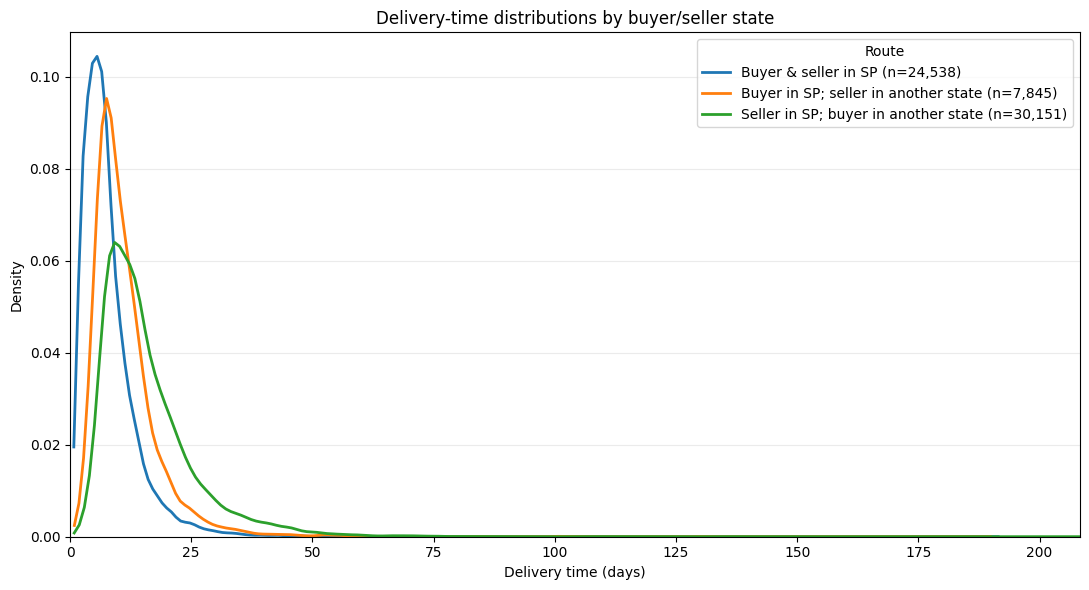

Development regression orders with lead_days > 100: 49
Maximum development regression lead_days: 209.63


In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ML = ROOT / "data" / "business" / "ml"

features = pd.read_csv(ML / "orders_ml_features.csv", low_memory=False)
splits = pd.read_csv(
    ML / "split_assignments.csv",
    usecols=["order_id", "split_assignment"],
)

# Limit the plot to eligible development rows for the delivery-time task.
reg = features.merge(splits, on="order_id", validate="one_to_one")
reg = reg.loc[
    reg["split_assignment"].eq("development")
    & reg["eligible_regression"].eq(1)
].copy()

# Require both states to be known, then form the three requested routes.
known_states = reg["customer_state"].notna() & reg["primary_seller_state"].notna()
buyer_sp = reg["customer_state"].eq("SP")
seller_sp = reg["primary_seller_state"].eq("SP")

reg["route"] = pd.NA
reg.loc[known_states & buyer_sp & seller_sp, "route"] = (
    "Buyer & seller in SP"
)
reg.loc[known_states & buyer_sp & ~seller_sp, "route"] = (
    "Buyer in SP; seller in another state"
)
reg.loc[known_states & ~buyer_sp & seller_sp, "route"] = (
    "Seller in SP; buyer in another state"
)

plot_df = reg.loc[reg["route"].notna()].copy()

fig, ax = plt.subplots(figsize=(11, 6))
for route, group in plot_df.groupby("route", observed=True):
    sns.kdeplot(
        data=group,
        x="lead_days",
        ax=ax,
        label=f"{route} (n={len(group):,})",
        common_norm=False,
        cut=0,
        fill=False,
        linewidth=2,
    )

ax.set(
    title="Delivery-time distributions by buyer/seller state",
    xlabel="Delivery time (days)",
    ylabel="Density",
    xlim=(0, plot_df["lead_days"].max()),
)
ax.legend(title="Route")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Report the tail as well as plotting it, so long delivery times are visible.
print("Development regression orders with lead_days > 100:",
      int(reg["lead_days"].gt(100).sum()))
print("Maximum development regression lead_days:",
      f"{reg['lead_days'].max():.2f}")

In [2]:
import pandas as pd
from pathlib import Path

root = Path(r"C:\src\IT5006_prj")

orders = pd.read_csv(root / "data/preprocessed/olist_orders_dataset.csv",
                    dtype={"order_id": "string"})
items = pd.read_csv(root / "data/preprocessed/olist_order_items_dataset.csv",
                    dtype={"order_id": "string", "seller_id": "string"})
reviews = pd.read_csv(root / "data/preprocessed/olist_order_reviews_dataset.csv",
                      dtype={"order_id": "string"})

# Seller order counts
seller_orders = items[["order_id", "seller_id"]].drop_duplicates()
seller_order_counts = seller_orders.groupby("seller_id")["order_id"].nunique()

repeat_sellers = (seller_order_counts > 1).sum()
total_sellers = seller_order_counts.index.nunique()
repeat_rate = repeat_sellers / total_sellers

print(f"Repeat sellers: {repeat_sellers:,}/{total_sellers:,}")
print(f"Repeat seller proportion: {repeat_rate:.2%}")

# Review binning per seller
review_per_order = reviews.groupby("order_id").size().rename("review_count").reset_index()
seller_review_counts = (
    seller_orders
    .merge(review_per_order, on="order_id", how="left")
    .fillna({"review_count": 0})
    .groupby("seller_id")["review_count"]
    .sum()
)

bins = pd.cut(
    seller_review_counts,
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5, float("inf")],
    labels=["0", "1", "2", "3", ">3"],
    right=True
)

print(pd.Series(bins).value_counts().sort_index().to_dict())

Repeat sellers: 2,524/3,095
Repeat seller proportion: 81.55%
{'0': 5, '1': 568, '2': 350, '3': 221, '>3': 1951}


### Written observations (evidence + proposed experiments)

These are read-only findings from the tables above; nothing is deleted, imputed
or transformed here. Exact values are in the printed tables.

1. **Strong right-skew in money/weight/volume/distance.** `total_price`,
   `total_freight`, `total_weight_g`, `total_volume_cm3` and `distance_km_max`
   show `p50 ≪ mean` and `p99 ≫ p75` (large positive `skew`). Proposed
   experiment (later training phase, as a named variant): log / Box–Cox
   transform of strictly-positive money/weight/volume features for
   linear/logistic models; trees are scale-invariant and need no transform.

2. **Deterministic missingness-indicator redundancy.** By construction
   `has_items == int(n_items > 0)`, `freight_ratio_missing ==
   int(freight_ratio is null)` and `payment_missing == int(no usable payment)`.
   These are intentional missingness indicators retained per §11.3 ("retain all
   27 input columns"); they are flagged, not removed.

3. **Item-count multicollinearity.** `n_products`, `n_sellers` and
   `n_categories` grow with `n_items` (and `total_freight` with `total_price`),
   so the strongest pairwise numeric correlations are among these counts.
   Expected; trees absorb it, while linear models would need care with
   coefficient interpretation — do not compare coefficients across folds by
   position (§11.3).

4. **Geography coverage is uneven by state.** `distance_km_max` (and its
   `distance_missing_fraction`) is missing for a small share of orders
   (~2% full-population), but the full-population quality report shows it
   concentrates in specific states — DF ~9%, SC ~2–5%, RO ~2.5–4.8%. This
   reflects ZIP/state keys with no in-polygon surviving coordinate or an
   out-of-country median, not random missingness. Proposed experiment: a
   separately versioned historical-reference lookup for those states.

5. **Item-dimension and category missingness propagate.** `total_weight_g` /
   `total_volume_cm3` are null where any item dimension is invalid (→
   `weight_missing_fraction` / `volume_missing_fraction` > 0), and
   `category_missing_fraction` > 0 where items lack a translated category.
   `total_price` / `total_freight` are null for the small no-items cohort.
   These nulls are legitimate pipeline nulls left for fold-fitted imputation.

6. **Class imbalance (classification).** `is_detractor` ≈ 15% vs ≈ 85% in the
   development population (match the full-population 14,533 / 98,673 ≈ 14.7%).
   Stratified CV already preserves both classes per fold. Proposed: report
   precision/recall/PR-AUC and a threshold decision on the validation fold,
   not accuracy alone; only rebalance sampling with evidence from a held-out
   baseline.

7. **Calendar codes are categorical, not ordinal.** `purchase_month` (1–12),
   `purchase_dayofweek` (0–6) and `purchase_hour` (0–23) are nominal codes and
   must be one-hot encoded (§11.3), never treated as a single numeric scale.

No feature is dropped on the basis of these observations — any approved removal
would be a named variant with its own rationale and re-run.

## 6. Reproducibility

- The data files (`orders_ml_features.csv`, `zip_centroids.csv`,
  `split_assignments.csv`, `cv_assignments.csv`) are byte-identical across runs
  (no timestamps in the data). The JSON reports carry `run_timestamp` /
  `retrieved_at` metadata fields, so only those fields differ between runs.
- Deterministic seeds: outer/inner CV use `random_state=42`; primary item/payment
  tie-breaks and all sort orders use `kind="mergesort"`.
- The geography `_point_covers` helper is exactly boundary-inclusive: a fast
  `contains_xy` interior pass plus an exact `covers` re-check on the tiny
  non-interior set (full geolocation table: 738,332 rows → 738,303 accepted,
  29 outside the polygon).
- To run without the notebook:

  ```
  python -m src.features.build_features
  python -m src.features.create_splits
  ```

- Training-fitted imputation/scaling/encoding, seller outcome histories and
  `T_pred` are intentionally **not** implemented this round; the §9 checks that
  depend on them are recorded under `quality_report.json → deferred_checks`.